# GWTC-3 mass-spin inference
#### Code: [gppop/spin-dev](https://github.com/AnaryaRay1/gppop/tree/spin-dev)

#### Contents 

- [Preamble](#Preamble), need to run.
- [Prepare Input for GWTC-3](#Prepare-input-for-GWTC-3)
- [Run Inference](#Run-inference)
- [GP sanity checks](#GP-sanity-checks)



## Preamble

In [64]:
import numpy as np
import pandas as pd
import h5py
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [65]:
import matplotlib.pyplot as plt
from matplotlib.ticker import (MultipleLocator, AutoMinorLocator,LogLocator,NullFormatter)
from matplotlib.colors import LogNorm
from matplotlib.colors import Normalize
import glob
import yaml
from astropy.cosmology import Planck15,z_at_value
from astropy import units as u
from scipy.interpolate import interp1d
import aesara.tensor as tt

In [66]:
import matplotlib
import matplotlib.pyplot as plt
matplotlib.rcParams['font.family'] = 'Times New Roman'
matplotlib.rcParams['font.sans-serif'] = ['Bitstream Vera Sans']
matplotlib.rcParams['text.usetex'] = True
matplotlib.rcParams['mathtext.fontset'] = 'cm'
matplotlib.rcParams['axes.unicode_minus'] = False
matplotlib.rcParams.update(matplotlib.rcParamsDefault)

import seaborn as sns
sns.set_context('talk')
sns.set_style('ticks')
sns.set_palette('colorblind')
colors=sns.color_palette('colorblind')
fs=80

In [67]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF

In [68]:
import pymc as pm

In [69]:
import arviz as az

In [70]:
from gwdistributions.distributions.spin.effective import IsotropicUniformMagnitudeChiEffGivenComponentMass

In [71]:
from gppop.core import Utils_spins,Utils,Utils_spins_with_q,Vt_Utils_spins,Vt_Utils_spins_with_q, Rates_spins,Rates_spins_with_q,Post_Proc_Utils_spins

In [72]:
from gppop.core import log_prob_spin, reweight_pinjection

In [73]:
mbins = np.logspace(np.log10(5), np.log10(200), 23)
chi_bins = np.array([-0.7,-0.6,-0.4,-0.3,-0.2,-0.1,-0.05, 0.0, 0.05, 0.1, 0.15,0.2,0.3,0.4,0.6,0.7])
qbins = np.array([0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0])

In [74]:
utils = Utils_spins_with_q(mbins,qbins,chi_bins,kappa=2.7)

## Prepare input for GWTC-4
Needs data on CIT to run, can skip directly to [this cell](#Plot-results)

In [75]:
Zs = np.linspace(0.,10,1000)
DLs = Planck15.luminosity_distance(Zs).value
z_interp = interp1d(DLs,Zs)

In [83]:
import os
os.chdir('/home/omkar.sridhar/NU_project_BGP/bbh-subpopulations-scripts/run-dir-gwtc4/')

In [84]:
with open('gwtc-4.yaml', "r") as stream:
    config = yaml.full_load(stream)

In [85]:
spin_prior = IsotropicUniformMagnitudeChiEffGivenComponentMass()
spin_prior._init_values(max_spin_magnitude=0.99)

In [86]:
N=1e6
import tqdm
for filename in tqdm.tqdm(config['pe_summary_event_dict'].values()):
    
    with h5py.File(filename[1],'r') as hf:
        try:
            if len(filename[0])>0:
                posterior = hf[filename[0]]['posterior_samples'][()]
            else:
                posterior = hf['posterior_samples'][()]
        except KeyError:
            
            posterior = hf['posterior']
            
        m1 = posterior['mass_1_source']
        if N>len(m1):
            N=len(m1)
        
print(N)

N_samples = N
np.random.seed(2**31-78)

spin_priors = [ ]


posterior_samples_o4 = np.zeros((len(config['pe_summary_event_dict'].keys()),N_samples,4))
for i,filename in enumerate(tqdm.tqdm(config['pe_summary_event_dict'].values())):
    
    testkey=False
    
    with h5py.File(filename[1],'r') as hf:
        try:
            if len(filename[0])>0:
                posterior = hf[filename[0]]['posterior_samples'][()]
            else:
                posterior = hf['posterior_samples'][()]
            this_N_samples = len(posterior)
        except KeyError:
            testkey=True
            posterior = hf['posterior']
            this_N_samples = len(posterior['mass_1_source'])
        indices = np.random.choice(this_N_samples,size=N_samples,replace=False)
        
        if not testkey:
            z = posterior['redshift'][indices]
            m1 = posterior['mass_1_source'][indices]
            m2 = posterior['mass_2_source'][indices]
            q = posterior['mass_ratio'][indices]
            chi_eff = posterior['chi_eff'][indices]
        else:
            z = posterior['redshift'][()][indices]
            m1 = posterior['mass_1_source'][()][indices]
            m2 = posterior['mass_2_source'][()][indices]
            q = posterior['mass_ratio'][()][indices]
            chi_eff = posterior['chi_eff'][()][indices]
        posterior_samples_o4[i,:,:] = np.array([m1,q,z,chi_eff]).T
        spin_priors.append(np.exp(spin_prior._logprob(chi_eff,m1,m2,0.99)))
        
posterior_samples_all = posterior_samples_o4.copy()
posterior_samples_o4 = [ ]
spin_priors = np.array(spin_priors)

100%|██████████| 153/153 [00:46<00:00,  3.28it/s]


1993


  0%|          | 0/153 [00:00<?, ?it/s]/home/omkar.sridhar/.conda/envs/gppop-dev-spin/lib/python3.9/site-packages/gwdistributions/distributions/spin/effective.py:236: RuntimeWarning: invalid value encountered in log
  ans = q*amax*(4 + 2*be.log(amax) - be.log(q**2*amax**2 - (1+q)**2 * chi**2)) \
/home/omkar.sridhar/.conda/envs/gppop-dev-spin/lib/python3.9/site-packages/gwdistributions/distributions/spin/effective.py:237: RuntimeWarning: invalid value encountered in arctanh
  - 2*(1+q)*chi * be.arctanh((1+q)*chi/(q*amax)) \
/home/omkar.sridhar/.conda/envs/gppop-dev-spin/lib/python3.9/site-packages/gwdistributions/distributions/spin/effective.py:253: RuntimeWarning: invalid value encountered in arctanh
  - 2*(1+q)*chi*be.arctanh(q*amax/((1+q)*chi)) \
/home/omkar.sridhar/.conda/envs/gppop-dev-spin/lib/python3.9/site-packages/gwdistributions/distributions/spin/effective.py:254: RuntimeWarning: invalid value encountered in log
  - q*amax*be.log((1+q)**2*chi**2 - q**2*amax**2) \
/home/omkar.

In [87]:
posterior_samples_all.shape


(153, 1993, 4)

In [88]:
spin_priors = np.array(spin_priors)
spin_priors[np.where(np.isnan(spin_priors))]=np.nanmin(spin_priors)

In [89]:
log_bin_centers=utils.generate_log_bin_centers_with_q()
tril_deltaLogbin = utils.arraynd_to_tril(utils.deltaLogbin_with_q())

In [90]:
weights = [ ]
wt_means = [ ]
wt_sigmas = [ ]
for i,posterior_samples_this_event in enumerate(posterior_samples_all):
    weight_set = utils.compute_weights_with_q(posterior_samples_this_event,chi_prior=spin_priors[i], O4_prior = True)
    weights.append(utils.arraynd_to_tril(weight_set[0]))
    wt_means.append(utils.arraynd_to_tril(weight_set[1]))
    wt_sigmas.append(utils.arraynd_to_tril(weight_set[2]))
    #weights.append(compute_weights_with_q(utils, posterior_samples_this_event,chi_prior=spin_priors[i]))
    if i%10==0:
        print(i)

0
10
20
30
40
50
60
70
80
90
100
110
120
130
140
150


In [91]:
weights = np.array(weights)
wt_means = np.array(wt_means)
wt_sigmas = np.array(wt_sigmas)

In [92]:
import os
os.getcwd()
os.chdir('Case_9mdo/')
#os.chdir('../test/gwtc4-clean_case_9mdo')

In [93]:
np.savetxt('wt_means_GWTC4_newbins3_with_q_case_9mdo.txt',wt_means)
np.savetxt('wt_sigmas_GWTC4_newbins3_with_q_case_9mdo.txt',wt_sigmas)

In [94]:
wts_sum = np.sum(weights,axis=0)

In [95]:
weights.shape

(153, 2640)

(22, 8, 15)


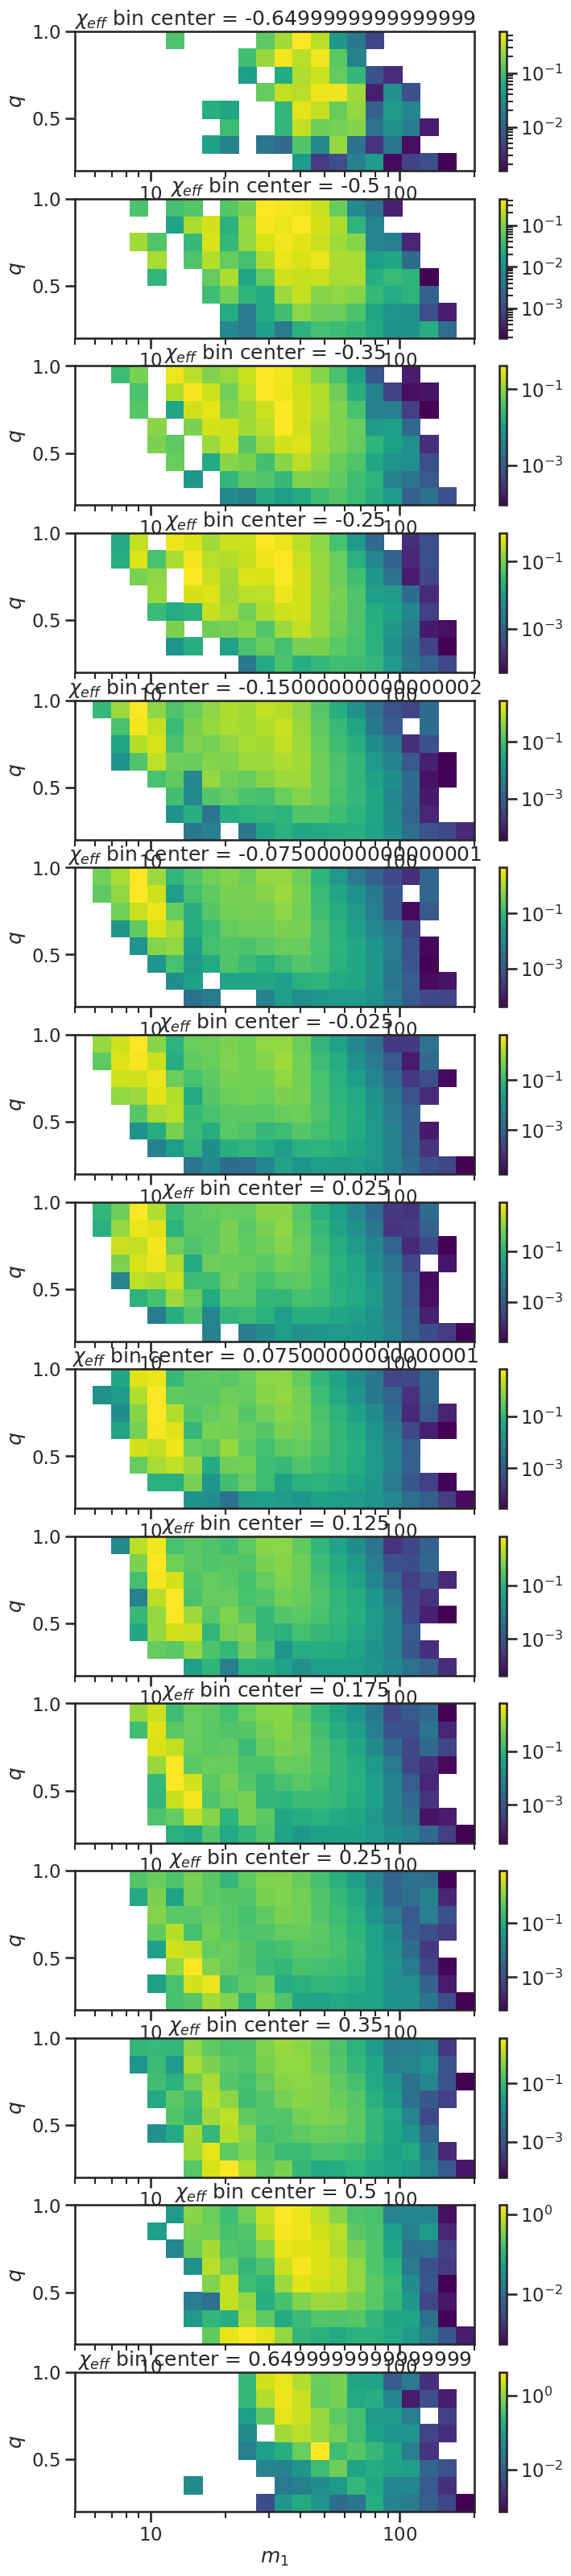

In [96]:
fig,axes = plt.subplots(len(chi_bins)-1,figsize=(8,40))
wts_sum = np.sum(weights,axis=0)
w= utils.construct_1dtond_matrix_with_q(len(mbins)-1,wts_sum,nbins_chi=len(chi_bins)-1, nbins_q = len(qbins) - 1)
#w = wts_sum
print(w.shape)
for i in range(len(chi_bins)-1):
        ax = axes[i]
        ax.set_title(r'$\chi_{eff}$ bin center = '+str(0.5*(chi_bins[i+1]+chi_bins[i])))
        matrix1 = w[:,:,i]
        if(matrix1.min()==matrix1.max()):
            continue

        pc = ax.pcolor(mbins,qbins,matrix1.T,norm=LogNorm(vmin=matrix1[matrix1!=0].min(),vmax=matrix1.max()),cmap='viridis')
        ax.set_xscale('log')
        #ax.set_yscale('log')
        ax.set_xlabel(r'$m_1$')
        ax.set_ylabel(r'$q$')
        plt.colorbar(pc, ax = ax)
    #fig.colorbar()
plt.show()
#plt.savefig('weights_chi_bin_center_plots_case_9mdo.pdf')

In [98]:
vt_utils = Vt_Utils_spins_with_q(mbins,qbins,chi_bins,kappa=2.7)

In [99]:
inj_dataset = {}
with h5py.File(config['injection_file'],'r') as hf:
    #print(hf['events'][()].dtype)
    
    m2 = hf["events"][()]["mass2_source"]
    inj_dataset['analysis_time_s'] = hf.attrs['total_analysis_time'] # years
    inj_dataset['total_generated'] = hf.attrs['total_generated']
    mix_weights = hf['events'][()]['weights']
    for param,key in config['injection_keys'].items():
            inj_dataset[param] = hf['events'][()][key]

chi_eff = (inj_dataset['mass1_source']*inj_dataset['spin1z']+
           inj_dataset['mass2_source']*inj_dataset['spin2z'])/(inj_dataset['mass1_source']+
                                                                        inj_dataset['mass2_source'])
inj_dataset['p_draw_chi_given_m1m2'] = np.exp(spin_prior._logprob(chi_eff,inj_dataset['mass1_source'],inj_dataset['mass2_source'],0.99))
thresh = config['threshold']
thresh_keys = config['threshold_keys']
for key in thresh_keys:
    if 'o1o2' in key:
        continue
    inj_dataset[key] = 1./inj_dataset[key] 
inj_dataset["mixture_weight"] = mix_weights
inj_dataset["sampling_pdf"] = np.exp(inj_dataset["sampling_pdf"])

In [100]:
vt_means,vt_sigmas = vt_utils.compute_VTs_for_q(inj_dataset,thresh,key = thresh_keys )

In [102]:
np.savetxt('vt_means_GWTC4_newbins3_with_q_case_9mdo.txt',vt_means)
np.savetxt('vt_sigmas_GWTC4_newbins3_with_q_case_9mdo.txt',vt_sigmas)

In [103]:
vts_nd = utils.construct_1dtond_matrix_with_q(len(mbins)-1,vt_means,nbins_chi=len(chi_bins)-1, nbins_q = len(qbins) - 1)

In [104]:
#arg = np.where(matrix1[np.tril_indices(len(matrix1))]==0)[0]
arg = np.where(matrix1==0)[0]
print(arg)


[ 0  0  0  0  0  0  0  0  1  1  1  1  1  1  1  1  2  2  2  2  2
  2  2  2  3  3  3  3  3  3  3  3  4  4  4  4  4  4  4  4  5  5
  5  5  5  5  5  5  6  6  6  6  6  6  6  7  7  7  7  7  7  7  7
  8  8  8  8  8  8  8  8  9  9  9 10 10 19 20 20 21 21 21 21 21
 21 21]


In [105]:
nbins_m = len(mbins)-1
#nbins_m = int(nbins_m*(nbins_m+1))
nbins_q = len(qbins) - 1 
nbins_chi = len(chi_bins)-1
args = np.array([ ])
for i in range(nbins_chi-1):
    args = np.append(args,nbins_m*i+arg)
args=args.astype(int)


In [106]:
nbins_m*i+arg

array([286, 286, 286, 286, 286, 286, 286, 286, 287, 287, 287,
       287, 287, 287, 287, 287, 288, 288, 288, 288, 288, 288,
       288, 288, 289, 289, 289, 289, 289, 289, 289, 289, 290,
       290, 290, 290, 290, 290, 290, 290, 291, 291, 291, 291,
       291, 291, 291, 291, 292, 292, 292, 292, 292, 292, 292,
       293, 293, 293, 293, 293, 293, 293, 293, 294, 294, 294,
       294, 294, 294, 294, 294, 295, 295, 295, 296, 296, 305,
       306, 306, 307, 307, 307, 307, 307, 307, 307])

In [107]:
np.savetxt('weights_GWTC4_IFAR1_m1m2chi_newbins3_with_q_case_9mdo.txt',weights)

In [108]:
np.savetxt('vts_GWTC4_IFAR1_m1m2chi_newbins3_with_q_case_9mdo.txt',np.matrix.flatten(vts_nd)/tril_deltaLogbin)

In [109]:
np.savetxt('mbins_with_q_case_9mdo.txt',mbins)
np.savetxt('chi_bins_new3_with_q_case_9mdo.txt',chi_bins)
np.savetxt('qbins_with_q_case_9mdo.txt', qbins)

In [110]:
dist_array = np.zeros(int(nbins_m*(nbins_m+1)/2))

chi_bin_centers = log_bin_centers[0:nbins_chi,2]
q_bin_centers = log_bin_centers[0:nbins_q * nbins_chi: nbins_chi, 1]
logm_bin_centers = log_bin_centers[0::nbins_chi * nbins_q, 0]
k=0
for i in range(len(logm_bin_centers)):
    for j in range(i+1):
        dist_array[k] = np.linalg.norm(logm_bin_centers[i]-logm_bin_centers[j])
        k+=1

scale_min = np.log(np.min(dist_array[dist_array!=0.]))
scale_max = np.log(np.max(dist_array))
scale_mean_m = 0.5*(scale_min + scale_max) # chosen to give coverage over the bin-grid
scale_sd_m = (scale_max - scale_min)/4 # fix 3-sigma difference to the sd of the length scale dist

dist_array = np.zeros(int(nbins_q*(nbins_q+1)/2))
k=0
for i in range(len(q_bin_centers)):
    for j in range(i+1):
        dist_array[k] = np.linalg.norm(q_bin_centers[i]-q_bin_centers[j])
        k+=1

scale_min = np.log(np.min(dist_array[dist_array!=0.]))
scale_max = np.log(np.max(dist_array))
scale_mean_q = 0.5*(scale_min + scale_max) # chosen to give coverage over the bin-grid
scale_sd_q = (scale_max - scale_min)/4 # fix 3-sigma difference to the sd of the length scale dist
print(scale_mean_m,scale_sd_m,scale_mean_q,scale_sd_q)

dist_array = np.zeros(int(nbins_chi*(nbins_chi+1)))
k=0
for i in range(len(chi_bin_centers)):
    for j in range(i+1):
        dist_array[k] = np.linalg.norm(chi_bin_centers[i]-chi_bin_centers[j])
        k+=1

scale_min = np.log(np.min(dist_array[dist_array!=0.]))
scale_max = np.log(np.max(dist_array))
scale_mean_chi = 0.5*(scale_min + scale_max) # chosen to give coverage over the bin-grid
scale_sd_chi = (scale_max - scale_min)/4 # fix 3-sigma difference to the sd of the length scale dist
print(scale_mean_chi,scale_sd_chi)

-0.2634584935333706 0.7611306094308572 -1.3296300184663896 0.4864775372638286
-1.3666840045432502 0.8145241345053705


In [111]:
np.savetxt('gp_inputs_newbins3_with_q_case_9mdo.txt',np.array([scale_mean_m,scale_sd_m, scale_mean_q,scale_sd_q, scale_mean_chi,scale_sd_chi]))